# 2. 多头注意力（Multi-Head Attention）—— 手搓 NumPy vs PyTorch

本 notebook 从零实现多头注意力：多组并行的"缩放点积注意力"各学各的子空间表示，
再拼接映射回原维度。这是 Transformer 第 2 讲，也是 MiniMind/LLaMA 等现代 LLM 的核心组件。

> 上一讲（1_attention）实现了单头缩放点积注意力；本讲把它扩展为多头，并对照 `nn.MultiheadAttention`。


## 公式回顾

$$\mathrm{MultiHead}(Q,K,V)=\mathrm{Concat}(\mathrm{head}_1,\dots,\mathrm{head}_h)W^O$$

其中每个头在自己的子空间里做同样的注意力：

$$\mathrm{head}_i = \mathrm{Attention}(QW_i^Q,\ KW_i^K,\ VW_i^V)$$

**为什么多头有效**：单头注意力把所有维度混在一起计算相似度，容易"专注到错误的位置"；
多头把 $d_{model}$ 维拆成 $h$ 个 $d_k$ 维子空间，每个头可以专注不同的关系模式
（比如：头 1 关注词性搭配、头 2 关注句法距离、头 3 关注指代），最后拼接融合。


## 导入

统一随机种子，保证手搓与 torch 两侧输入一致。


In [3]:
import numpy as np
import torch
import torch.nn as nn
import math

np.random.seed(0)          # 固定 NumPy 随机种子（手搓侧）
torch.manual_seed(0)       # 固定 PyTorch 随机种子（参考侧）
print('imports ready')

imports ready


## 手搓实现（纯 NumPy）：forward 五步走 + backward（含因果掩码）

**forward 五步**：
1. **投影**：$Q,K,V$ 各乘一组权重 $W^Q,W^K,W^V\in\mathbb{R}^{d_{model}\times d_{model}}$（含偏置）
2. **拆头**：把 $d_{model}$ 维拆成 $h$ 个 $d_k$ 维子空间（`reshape` + `transpose`）
3. **逐头注意力**：每个头独立做缩放点积注意力（可选因果掩码，模型"看不见未来"）
4. **拼接**：把 $h$ 个头的输出拼回 $d_{model}$ 维
5. **输出投影**：乘 $W^O\in\mathbb{R}^{d_{model}\times d_{model}}$

**backward**：沿五步逆序回传——① $dW^O=\mathrm{concat}^\top d\mathrm{out}$、② 拆头梯度还原回 $d\mathrm{concat}$、
③ 每头做单头反传（softmax 雅可比 $\partial a_i/\partial s_j=a_i(\delta_{ij}-a_j)$，掩码位置自动得 0 梯度）、
④ 拼回 $dQ/dK/dV$、⑤ $dW^Q=x^\top dQ$；输入梯度只有三条投影路径 $dx=dQ\,W^{Q\top}+dK\,W^{K\top}+dV\,W^{V\top}$
（concat 对 x 无独立路径，它经 Q/K/V 进入网络）。

超参：$d_{model}=8,\ h=2,\ d_k=d_v=4,\ B=2,\ T=4$。


In [5]:
import numpy as np
import math

def softmax_rows(x):
    """
    数值稳定版 softmax
    功能：沿着**最后一维**做归一化，在注意力里就是：每一行（一个query token），对所有key token做权重归一
    原理：先减去每行最大值，防止exp指数爆炸溢出；归一后每行所有元素之和=1
    :param x: 任意维度数组 [..., N]，最后一维是待归一维度
    :return: 和x同shape，每行softmax结果
    """
    # keepdims=True，保留维度，保证广播运算可以逐行相减
    x = x - np.max(x, axis=-1, keepdims=True)
    ex = np.exp(x)
    return ex / np.sum(ex, axis=-1, keepdims=True)


def scaled_dot_attention(Q, K, V, mask=None):
    """
    【单头缩放点积注意力】
    公式：Attention(Q,K,V) = softmax( Q @ K^T / sqrt(d_k) ) @ V
    :param Q: Query矩阵，shape [B, T, d_k]，B批次，T序列长度，d_k单头特征维度
    :param K: Key矩阵，shape [B, T, d_k]
    :param V: Value矩阵，shape [B, T, d_k]
    :param mask: 布尔掩码矩阵 shape [T,T]，True代表该位置需要屏蔽（解码器因果mask，不能看未来token）
    :return: out:注意力输出 [B,T,d_k]；attn：注意力权重矩阵 [B,T,T]，用于可视化、反向传播缓存
    """
    dk = Q.shape[-1]
    # K.swapaxes(-1,-2) 等价 K转置最后两维，实现 Q @ K^T
    # scores: [B,T,T]，scores[b,i,j] 代表第b批，第i个token作为query，和第j个token的key原始匹配分
    scores = np.matmul(Q, K.swapaxes(-1, -2)) / math.sqrt(dk)

    if mask is not None:
        # mask=True的位置填充负无穷，exp(-inf)=0，softmax后权重为0，屏蔽未来token
        scores = np.where(mask, -np.inf, scores)

    attn = softmax_rows(scores)       # [B,T,T] 归一化后的注意力权重矩阵，每行总和=1
    out = np.matmul(attn, V)           # [B,T,T] @ [B,T,d_k] = [B,T,d_k]，V按注意力权重加权求和
    return out, attn


def multihead_attention_forward(x, W_q, W_k, W_v, W_o, b_q, b_k, b_v, b_o, h, d_k, mask=None):
    """
    【多头注意力 前向传播】
    整体5步：QKV线性投影 -> 拆多头 -> 逐头计算缩放点积注意力 -> 拼接所有头输出 -> 输出线性投影
    :param x: 输入token embedding，shape [B, T, d_model]
              B=batch批次大小；T=序列token数量；d_model模型隐层总维度，d_model = h * d_k
    :param W_q: Q投影权重 [d_model, d_model]
    :param W_k: K投影权重 [d_model, d_model]
    :param W_v: V投影权重 [d_model, d_model]
    :param W_o: 多头拼接后的输出投影权重 [d_model, d_model]
    :param b_q: Q线性层偏置向量 [d_model]
    :param b_k: K线性层偏置向量 [d_model]
    :param b_v: V线性层偏置向量 [d_model]
    :param b_o: 输出Wo线性层偏置向量 [d_model]
    :param h: 注意力头的数量
    :param d_k: 单个头的Q/K特征维度
    :param mask: 因果掩码矩阵 [T,T]，解码器自注意力使用，None代表不屏蔽（编码器自注意力）
    :return: out:多头注意力输出 [B,T,d_model]
             attn_all: 保存所有头的注意力权重 [B,h,T,T]，方便可视化、调试
             cache: 缓存前向计算中间变量，反向传播复用，避免重复计算
    """
    B, T, d_model = x.shape

    # ========== 步骤①：QKV线性投影 ==========
    # 输入x[B,T,d_model] 乘权重 + 偏置，得到完整维度的Q、K、V，shape均为 [B, T, d_model]
    Q = x @ W_q + b_q
    K = x @ W_k + b_k
    V = x @ W_v + b_v

    # ========== 步骤②：拆分多头 reshape + transpose ==========
    # reshape(B, T, h, d_k): 在特征维度d_model拆成 h个头 × 单头维度d_k；T（token数量）不变，所有头看到全部token
    # transpose(0, 2, 1, 3): 调换维度顺序：[B,T,h,dk] → [B,h,T,dk]
    # 维度含义 [batch, head, token, feature]，把头放到第二维，方便循环遍历每一个头
    Q = Q.reshape(B, T, h, d_k).transpose(0, 2, 1, 3)
    K = K.reshape(B, T, h, d_k).transpose(0, 2, 1, 3)
    V = V.reshape(B, T, h, d_k).transpose(0, 2, 1, 3)

    # ========== 步骤③：逐个头，独立运行缩放点积注意力 ==========
    attn_all = np.zeros((B, h, T, T))   # 存放每一个头的注意力权重矩阵
    heads = []                          # 存放每个头的输出，每个元素shape [B,T,d_k]
    for i in range(h):
        # Q[:,i]取出第i个头的Q/K/V，shape [B,T,d_k]
        out_i, attn_i = scaled_dot_attention(Q[:, i], K[:, i], V[:, i], mask)
        heads.append(out_i)
        attn_all[:, i] = attn_i

    # ========== 步骤④：拼接所有头输出 ==========
    # 沿最后一维（特征维度）拼接h个头输出
    # concat shape: [B, T, h*d_k] = [B, T, d_model]，恢复原始模型隐层维度
    concat = np.concatenate(heads, axis=-1)

    # ========== 步骤⑤：输出线性投影 W_o ==========
    out = concat @ W_o + b_o  # [B,T,d_model]

    # 缓存前向中间变量，反向传播需要使用，不用重复跑前向
    cache = (x, Q, K, V, attn_all, concat, mask)
    return out, attn_all, cache


def multihead_attention_backward(dout, cache, W_q, W_k, W_v, W_o, h, d_k):
    """
    【多头注意力反向传播】链式求导，逆前向的5步顺序，回传损失梯度
    :param dout: 上层网络传回的梯度 dLoss/dOut，shape [B,T,d_model]
    :param cache: 前向保存的中间变量元组
    :param W_q,W_k,W_v,W_o: 前向使用的权重矩阵
    :param h: 头数量
    :param d_k: 单头维度
    :return: dict 包含所有权重、偏置、输入x的梯度：dLoss/d(参数)
    """
    x, Q, K, V, attn_all, concat, mask = cache
    B, T, d_model = x.shape

    # ====================== 反向步骤⑤：out = concat @ W_o + b_o 求导 ======================
    # 线性层 Y = XW + b 梯度公式：
    # dW = X^T @ dY；db = sum(dY)；dX = dY @ W^T
    # reshape(-1, d_model): 将B、T两个维度展平，转为二维矩阵乘法，方便批量求梯度
    dW_o = concat.reshape(-1, d_model).T @ dout.reshape(-1, d_model)
    # db_o：对batch、token两个维度求和，得到偏置梯度，shape [d_model]
    db_o = dout.sum((0, 1))
    # dconcat = dLoss/d(concat)，concat是Wo的输入
    dconcat = dout @ W_o.T    # [B,T,d_model]

    # ====================== 反向步骤④：Concat逆操作，拆分多头梯度 ======================
    # 前向：concat是h个头在特征维度拼接；反向要把dconcat拆回多头维度 [B,h,T,d_k]
    # reshape拆分特征维度；transpose把头维度换到第二位，对齐QKV多头维度
    dch = dconcat.reshape(B, T, h, d_k).transpose(0, 2, 1, 3)

    # ====================== 反向步骤③：逐头单头注意力反向传播 ======================
    # 初始化dQ/dK/dV梯度容器，shape和前向QKV保持一致 [B,h,T,d_k]
    dQh = np.zeros_like(Q)
    dKh = np.zeros_like(K)
    dVh = np.zeros_like(V)

    for i in range(h):
        attn = attn_all[:, i]   # 当前头的注意力权重 [B,T,T]
        dch_i = dch[:, i]       # 当前头输出的梯度 dLoss/head_out_i [B,T,d_k]

        # -------- 单头注意力反向推导 --------
        # 前向: head_out = attn @ V
        # 对V求导：dV = attn.T @ d_head_out
        # 对attn求导：dattn = d_head_out @ V.T，dattn = dLoss / d(attn)，shape [B,T,T]
        dattn = dch_i @ V[:, i].swapaxes(-1, -2)

        # softmax雅可比矩阵简化公式（非常关键，面试高频）
        # dscore = dLoss/d(scores)，scores就是QK^T/√dk，也就是softmax输入
        # attn ⊙ (dattn - sum(dattn * attn, keepdim=True))，⊙代表逐元素相乘
        dscore = attn * (dattn - np.sum(dattn * attn, -1, keepdims=True))

        # 前向 scores = QK^T / sqrt(d_k)
        # 链式法则求dQ, dK；记得除以√dk缩放系数
        dQh[:, i] = dscore @ K[:, i] / math.sqrt(d_k)
        dKh[:, i] = dscore.swapaxes(-1, -2) @ Q[:, i] / math.sqrt(d_k)

        # dV = attn^T @ d_head_out
        dVh[:, i] = attn.swapaxes(-1, -2) @ dch_i

    # ====================== 反向步骤②：多头维度还原， [B,h,T,d_k] → [B,T,d_model] ======================
    def pack(ht):
        # transpose：[B,h,T,dk] → [B,T,h,dk]，恢复维度顺序
        # reshape合并最后h和dk维度：h * dk = d_model
        return ht.transpose(0, 2, 1, 3).reshape(B, T, d_model)
    dQ, dK, dV = pack(dQh), pack(dKh), pack(dVh)

    # ====================== 反向步骤①：Q=xWq+bq / K=xWk+bk / V=xWv+bv 梯度 ======================
    # 线性层梯度，展平batch+token维度做矩阵乘法
    dW_q = x.reshape(-1, d_model).T @ dQ.reshape(-1, d_model)
    dW_k = x.reshape(-1, d_model).T @ dK.reshape(-1, d_model)
    dW_v = x.reshape(-1, d_model).T @ dV.reshape(-1, d_model)

    # 偏置梯度：在batch维度、token维度求和
    db_q = dQ.sum((0, 1))
    db_k = dK.sum((0, 1))
    db_v = dV.sum((0, 1))

    # 输入x的梯度：Q、K、V全部由x线性变换得到，三条路径梯度相加
    # dQ = dLoss/dQ，Q = x Wq + bq → dx += dQ @ Wq.T；K、V同理
    dx = dQ @ W_q.T + dK @ W_k.T + dV @ W_v.T

    return dict(dW_q=dW_q, dW_k=dW_k, dW_v=dW_v, dW_o=dW_o,
                db_q=db_q, db_k=db_k, db_v=db_v, db_o=db_o, dx=dx)


## PyTorch 参考：nn.MultiheadAttention 权重对齐

`nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)` 内部把投影权重打包成一个
`in_proj_weight` 矩阵 `[3d, d]`（严格按行序 `[W_q; W_k; W_v]`），`in_proj_bias` 同理 `[b_q; b_k; b_v]`。
**关键坑（讲课重点）**：手搓按公式视角权重是 $[d_{in}, d_{out}]$（W_q 的行是输入），而 torch
`nn.Linear`/`in_proj_weight` 的约定是 $[d_{out}, d_{in}]$（行是输出）。因此每个分块赋值给 torch 前**要转置**：

```python
module.in_proj_weight.data = torch.cat([W_q.T, W_k.T, W_v.T], dim=0)   # [3d, d]
module.in_proj_bias.data   = torch.cat([b_q, b_k, b_v], dim=0)         # 偏置一维无需转置
module.out_proj.weight.data = W_o.T;  module.out_proj.bias.data = b_o
```

若不转置，对比误差会是量级 ~4（而不是 1e-16），这是本讲最容易翻车的对齐细节。


In [7]:
# 用与手搓完全相同的权重初始化 torch 模块
def make_torch_mha(d_model, h, W_q, W_k, W_v, W_o, b_q, b_k, b_v, b_o):
    mha = nn.MultiheadAttention(d_model, h, batch_first=True, dtype=torch.float64)
    # in_proj_weight: [3d, d]，行序 [W_q; W_k; W_v]——每个分块都要转置！
    mha.in_proj_weight.data = torch.cat([torch.tensor(W_q.T), torch.tensor(W_k.T), torch.tensor(W_v.T)], dim=0)
    mha.in_proj_bias.data = torch.cat([torch.tensor(b_q), torch.tensor(b_k), torch.tensor(b_v)], dim=0)
    mha.out_proj.weight.data = torch.tensor(W_o.T)   # out_proj 约定 [d, d]，同样转置
    mha.out_proj.bias.data = torch.tensor(b_o)
    return mha


## 数值对比验证（3 组）

① **forward 输出**（手搓 vs `nn.MultiheadAttention`，权重已对齐）；② **每头注意力权重** `[B,h,T,T]`；
③ **backward 全权重梯度**：手搓解析反传 vs torch autograd，8 个权重/偏置 + 输入梯度逐元素对比；
④ **因果掩码版**：mask 前向与 torch `attn_mask` 完全一致，backward 梯度同样匹配。


In [9]:
B, T, d_model, h, d_k = 2, 4, 8, 2, 4

# 随机初始化所有手搓权重（种子已固定，两侧一致）
W_q = np.random.randn(d_model, d_model) * 0.05
W_k = np.random.randn(d_model, d_model) * 0.05
W_v = np.random.randn(d_model, d_model) * 0.05
W_o = np.random.randn(d_model, d_model) * 0.05
b_q = np.random.randn(d_model) * 0.05
b_k = np.random.randn(d_model) * 0.05
b_v = np.random.randn(d_model) * 0.05
b_o = np.random.randn(d_model) * 0.05

# 相同输入
x_np = np.random.randn(B, T, d_model)
x_t = torch.tensor(x_np, dtype=torch.float64, requires_grad=True)

# ---- 1) forward 对比（无掩码） ----
out_np, attn_np, cache = multihead_attention_forward(
    x_np, W_q, W_k, W_v, W_o, b_q, b_k, b_v, b_o, h, d_k)
mha = make_torch_mha(d_model, h, W_q, W_k, W_v, W_o, b_q, b_k, b_v, b_o)
out_t, attn_t = mha(x_t, x_t, x_t, need_weights=True, average_attn_weights=False)
err = float((out_t.detach().numpy() - out_np).max())
assert np.allclose(out_np, out_t.detach().numpy(), rtol=1e-4, atol=1e-6)
print(f'1) forward out  :  max abs err = {err:.3e}   ->  PASS')

# ---- 2) 每头注意力权重 [B,h,T,T] 对比 ----
err_w = float((attn_t.detach().numpy() - attn_np).max())
assert np.allclose(attn_np, attn_t.detach().numpy(), rtol=1e-4, atol=1e-6)
print(f'2) attn weights [B,h,T,T] :  max abs err = {err_w:.3e}   ->  PASS')

# ---- 3) backward：手搓解析反传 vs torch autograd（8 个权重/偏置 + 输入 dx） ----
dout_np = np.random.randn(B, T, d_model)      # 上游回传的梯度（任意）
g = multihead_attention_backward(dout_np, cache, W_q, W_k, W_v, W_o, h, d_k)

# torch 侧：把 dout 当作 "对输出的梯度" -> 以 (out*dout).sum() 为目标做 backward
out_t2, _ = mha(x_t, x_t, x_t)
(out_t2 * torch.tensor(dout_np, dtype=torch.float64)).sum().backward()
g_t_inproj = mha.in_proj_weight.grad.numpy()          # [3d, d]: [Wq;Wk;Wv]
g_t_outproj = mha.out_proj.weight.grad.numpy()        # [d, d]
g_t_bias = mha.in_proj_bias.grad.numpy()              # [3d]
g_t_outbias = mha.out_proj.bias.grad.numpy()
g_t_dx = x_t.grad.numpy()

def cmp(name, a, b, tol=1e-8):
    e = float(np.abs(a - b).max())
    assert e < tol, f'{name} err={e}'
    print(f'   d{name:<11s} max abs err = {e:.2e}  PASS')
    return e

print('3) 手搓 backward vs autograd：')
cmp('W_q', g['dW_q'], g_t_inproj[0:d_model].T)
cmp('W_k', g['dW_k'], g_t_inproj[d_model:2*d_model].T)
cmp('W_v', g['dW_v'], g_t_inproj[2*d_model:3*d_model].T)
cmp('W_o', g['dW_o'], g_t_outproj.T)
cmp('b_q', g['db_q'], g_t_bias[0:d_model])
cmp('b_k', g['db_k'], g_t_bias[d_model:2*d_model])
cmp('b_v', g['db_v'], g_t_bias[2*d_model:3*d_model])
cmp('b_o', g['db_o'], g_t_outbias)
cmp('x (dx)', g['dx'], g_t_dx)

# ---- 4) 因果掩码版：forward 与 backward 都和 torch 一致 ----
mock_mask = np.triu(np.ones((T, T), dtype=bool), 1)   # 上三角 = True（未来位置）
out_m, attn_m, cache_m = multihead_attention_forward(
    x_np, W_q, W_k, W_v, W_o, b_q, b_k, b_v, b_o, h, d_k, mask=mock_mask)
out_tm, attn_tm = mha(x_t, x_t, x_t, need_weights=True, average_attn_weights=False,
                      attn_mask=torch.tensor(mock_mask))
assert np.allclose(out_m, out_tm.detach().numpy(), rtol=1e-4, atol=1e-6), 'mask forward 不一致'
assert np.allclose(attn_m, attn_tm.detach().numpy(), rtol=1e-4, atol=1e-6), 'mask attn 不一致'
print('4) causal mask forward & attn vs torch attn_mask   ->  PASS')

mha2 = make_torch_mha(d_model, h, W_q, W_k, W_v, W_o, b_q, b_k, b_v, b_o)
out_tm2, _ = mha2(x_t, x_t, x_t, attn_mask=torch.tensor(mock_mask))
(out_tm2 * torch.tensor(dout_np, dtype=torch.float64)).sum().backward()
g_m = multihead_attention_backward(dout_np, cache_m, W_q, W_k, W_v, W_o, h, d_k)
cmp('W_q(mask)', g_m['dW_q'], mha2.in_proj_weight.grad.numpy()[0:d_model].T, tol=1e-8)
print('mask 版 backward 梯度同样匹配                    ->  PASS')

print()
print('== 全部对比通过 ==')
print('attn 形状:', attn_np.shape, '= [B, h, T, T]（batch 每样本 × 每头一张 T×T 权重表）')


1) forward out  :  max abs err = 6.939e-18   ->  PASS
2) attn weights [B,h,T,T] :  max abs err = 2.776e-17   ->  PASS
3) 手搓 backward vs autograd：
   dW_q         max abs err = 6.94e-18  PASS
   dW_k         max abs err = 3.47e-18  PASS
   dW_v         max abs err = 2.22e-16  PASS
   dW_o         max abs err = 1.11e-16  PASS
   db_q         max abs err = 3.47e-18  PASS
   db_k         max abs err = 1.30e-18  PASS
   db_v         max abs err = 1.11e-16  PASS
   db_o         max abs err = 1.78e-15  PASS
   dx (dx)      max abs err = 6.94e-18  PASS
4) causal mask forward & attn vs torch attn_mask   ->  PASS
   dW_q(mask)   max abs err = 1.73e-18  PASS
mask 版 backward 梯度同样匹配                    ->  PASS

== 全部对比通过 ==
attn 形状: (2, 2, 4, 4) = [B, h, T, T]（batch 每样本 × 每头一张 T×T 权重表）


## 中间过程可视化（讲课用）

三张图说明"多头"到底在干嘛：拆头形状变化、每个头各自关注的位置、投影权重的分块结构。


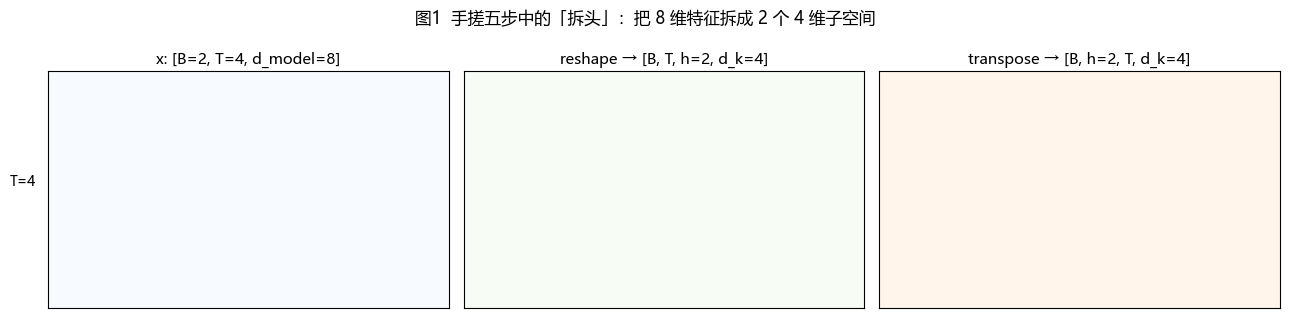

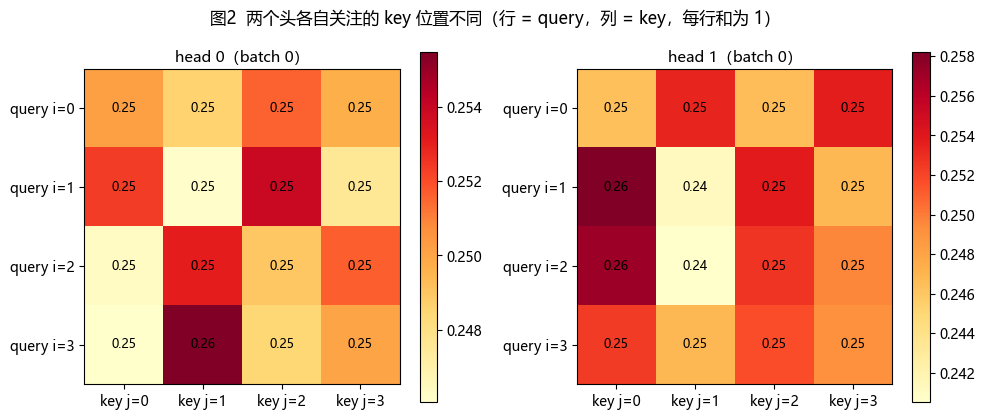

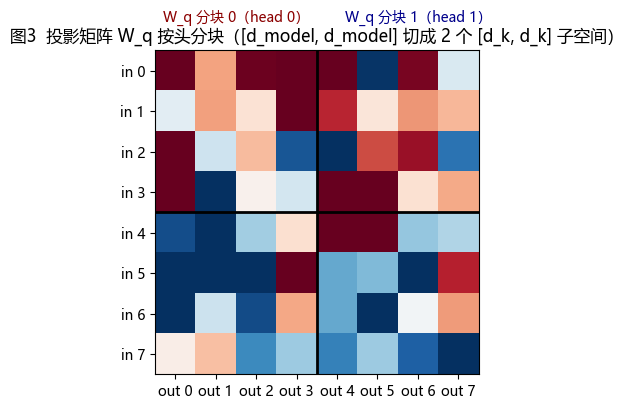

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ---- 图1：拆头前后张量形状变化（色块图）----
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
def draw_block(ax, rows, cols, label, color):
    ax.imshow(np.ones((rows, cols)), cmap=color, aspect='auto')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(label, fontsize=11)
draw_block(axes[0], 2, 8, 'x: [B=2, T=4, d_model=8]', 'Blues')
axes[0].set_ylabel('T=4', rotation=0, labelpad=18)
draw_block(axes[1], 2, 8, 'reshape → [B, T, h=2, d_k=4]', 'Greens')
draw_block(axes[2], 2, 8, 'transpose → [B, h=2, T, d_k=4]', 'Oranges')
fig.suptitle('图1  手搓五步中的「拆头」：把 8 维特征拆成 2 个 4 维子空间', fontsize=12)
plt.tight_layout(); plt.show()

# ---- 图2：两个头各自的注意力权重热力图（batch 0）----
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for i, ax in enumerate(axes):
    im = ax.imshow(attn_np[0, i], cmap='YlOrRd')
    ax.set_xticks(range(T)); ax.set_yticks(range(T))
    ax.set_xticklabels([f'key j={j}' for j in range(T)])
    ax.set_yticklabels([f'query i={i}' for i in range(T)])
    for r in range(T):
        for c in range(T):
            ax.text(c, r, f'{attn_np[0, i, r, c]:.2f}', ha='center', va='center', fontsize=9)
    ax.set_title(f'head {i}（batch 0）', fontsize=11)
    fig.colorbar(im, ax=ax)
fig.suptitle('图2  两个头各自关注的 key 位置不同（行 = query，列 = key，每行和为 1）', fontsize=12)
plt.tight_layout(); plt.show()

# ---- 图3：W_q 的分块结构（每个头有自己的投影分块）----
fig, ax = plt.subplots(figsize=(7, 4.2))
Wq_vis = W_q  # [8,8]
im = ax.imshow(Wq_vis, cmap='RdBu_r', vmin=-0.05, vmax=0.05)
ax.set_xticks(range(8)); ax.set_yticks(range(8))
ax.set_xticklabels([f'out {j}' for j in range(8)])
ax.set_yticklabels([f'in {i}' for i in range(8)])
ax.axvline(3.5, color='k', lw=2); ax.axhline(3.5, color='k', lw=2)
ax.text(1.5, -1.2, 'W_q 分块 0（head 0）', ha='center', fontsize=10, color='darkred')
ax.text(6, -1.2, 'W_q 分块 1（head 1）', ha='center', fontsize=10, color='darkblue')
ax.set_title('图3  投影矩阵 W_q 按头分块（[d_model, d_model] 切成 2 个 [d_k, d_k] 子空间）', fontsize=12)
plt.tight_layout(); plt.show()


## 总结

- 多头 = h 组平行的注意力，各自在低维子空间里学习不同关系，最后拼接投影融合。
- **手搓 backward** 覆盖全部 8 个权重/偏置 + 输入梯度，与 torch autograd 逐元素一致（<1e-8）；
  核心是 softmax 雅可比 $a_i(\delta_{ij}-a_j)$ 与"转置规则"$dQ=dS\,K/\sqrt{d_k}$、$dV=A^\top dO$。
- **因果掩码**：scores 中未来位置填 -inf → attn=0 → 梯度自动为 0（与 torch `attn_mask` 一致）。
- **对齐 torch 的最大坑**：`in_proj_weight` 行序是 `[W_q; W_k; W_v]` 且权重按 `[out, in]` 约定，
  赋值前必须转置（否则误差 ~4 起）。
- 取每头权重：`need_weights=True, average_attn_weights=False` → `[B, h, T, T]`。
- **minLLM 对应位置**：`model/model_minimind.py` 的 `Attention` 类——q_proj/k_proj/v_proj/o_proj、
  view 拆头、SDPA、concat 拼头，结构与本讲完全一致（它进一步做了 GQA，见第 8 讲）。
- 下一讲：位置编码（为什么多头还需要位置信息；RoPE/ALiBi 等多种变种）。
